# RANDOM FOREST — Car Dekho

Este notebook segue a mesma lógica do exemplo **Random Forest com `housing.csv`**, porém aplicado ao dataset **Car Details from CarDekho**.

## Objetivo

Criar um modelo de **regressão** para prever o preço de venda de veículos (`selling_price`) usando o algoritmo **Random Forest Regressor**.

## Dataset

Arquivo esperado na mesma pasta do notebook:

```text
CAR DETAILS FROM CAR DEKHO.csv
```

Variável alvo:

```text
selling_price
```


# Configuração do Ambiente Virtual

> Execute esta célula somente se ainda não configurou o ambiente.

No Windows/VS Code, caso a ativação do `.venv` esteja bloqueada pelo PowerShell, você pode instalar as bibliotecas diretamente pelo Python do ambiente virtual usando o terminal:

```powershell
.\.venv\Scripts\python.exe -m pip install pandas numpy matplotlib scikit-learn seaborn kagglehub ipykernel
.\.venv\Scripts\python.exe -m ipykernel install --user --name=car_dekho_env --display-name "Python Car Dekho (.venv)"
```

Depois, reinicie o VS Code:

```text
Ctrl + Shift + P → Developer: Reload Window
```

E selecione o kernel:

```text
Python Car Dekho (.venv)
```


In [5]:
# Célula 00 - Instalação das bibliotecas necessárias
# Execute apenas se o ambiente ainda não tiver as bibliotecas instaladas.

%pip install pandas numpy matplotlib scikit-learn seaborn kagglehub ipykernel

Note: you may need to restart the kernel to use updated packages.


# 1. Importação das Bibliotecas

Nesta etapa importamos os pacotes que serão usados no notebook.

Assim como no exemplo do `housing.csv`, usaremos:

* `pandas` para manipulação dos dados;
* `numpy` para operações numéricas;
* `matplotlib` para gráficos;
* `DecisionTreeRegressor` para comparar uma árvore simples;
* `RandomForestRegressor` para criar o modelo principal;
* métricas de regressão para avaliar os resultados.


In [1]:
# Célula 01 - Importando os pacotes necessários

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

from pathlib import Path

from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import seaborn as sns

# 2. Carregamento do Dataset

Nesta etapa carregamos o arquivo CSV e visualizamos as primeiras linhas.

O arquivo deve estar na mesma pasta do notebook.


In [2]:
# Célula 02 - Carregando nosso Dataset e visualizando as primeiras linhas

csv_path = Path("CAR DETAILS FROM CAR DEKHO.csv")

df = pd.read_csv(csv_path)
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [3]:
# Célula 03 - Quantidade de linhas e colunas do arquivo

df.shape

(4340, 8)

In [4]:
# Célula 04 - Informações gerais do dataset

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   name           4340 non-null   str  
 1   year           4340 non-null   int64
 2   selling_price  4340 non-null   int64
 3   km_driven      4340 non-null   int64
 4   fuel           4340 non-null   str  
 5   seller_type    4340 non-null   str  
 6   transmission   4340 non-null   str  
 7   owner          4340 non-null   str  
dtypes: int64(3), str(5)
memory usage: 271.4 KB


# 3. Entendimento das Variáveis

## Dicionário de Dados

* `name`: nome/modelo do veículo;
* `year`: ano de fabricação;
* `selling_price`: preço de venda do veículo;
* `km_driven`: quilometragem rodada;
* `fuel`: tipo de combustível;
* `seller_type`: tipo de vendedor;
* `transmission`: tipo de câmbio;
* `owner`: tipo/quantidade de proprietário anterior.

Como o objetivo é prever preço, a variável alvo será:

```python
selling_price
```


In [5]:
# Célula 05 - Estatísticas descritivas das variáveis numéricas

df.describe()

,year,selling_price,km_driven
count,4340.000000,4.340000e+03,4340.000000
mean,2013.090783,5.041273e+05,66215.777419
std,4.215344,5.785487e+05,46644.102194
min,1992.000000,2.000000e+04,1.000000
25%,2011.000000,2.087498e+05,35000.000000
50%,2014.000000,3.500000e+05,60000.000000
75%,2016.000000,6.000000e+05,90000.000000
max,2020.000000,8.900000e+06,806599.000000


In [6]:
# Célula 06 - Verificando valores nulos e duplicados

print("Valores nulos por coluna:")
print(df.isnull().sum())

print("\nLinhas duplicadas:")
print(df.duplicated().sum())

Valores nulos por coluna:
name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64

Linhas duplicadas:
763


# 4. Visualização Inicial dos Dados

Antes de treinar o modelo, vamos visualizar algumas relações importantes:

* preço de venda;
* quilometragem;
* ano do carro;
* relação entre quilometragem e preço;
* relação entre ano e preço.


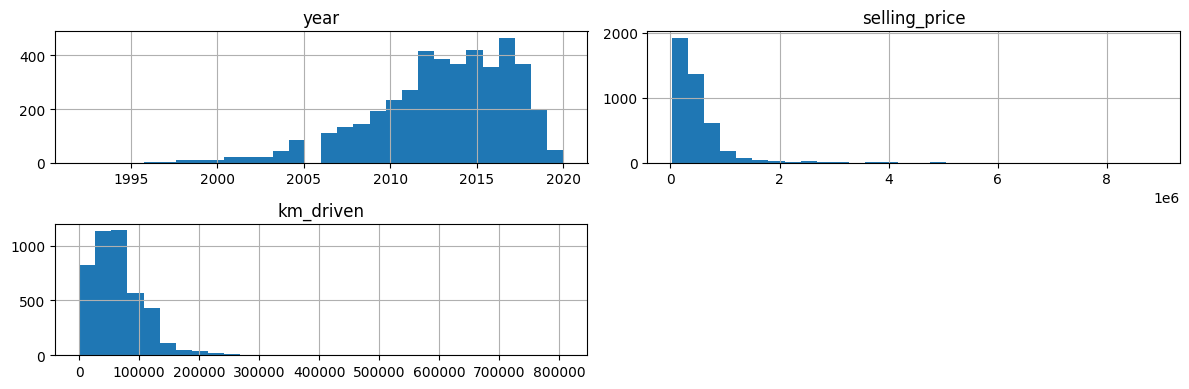

In [7]:
# Célula 07 - Histogramas das principais variáveis numéricas

df[["year", "selling_price", "km_driven"]].hist(figsize=(12, 4), bins=30)
plt.tight_layout()
plt.show()

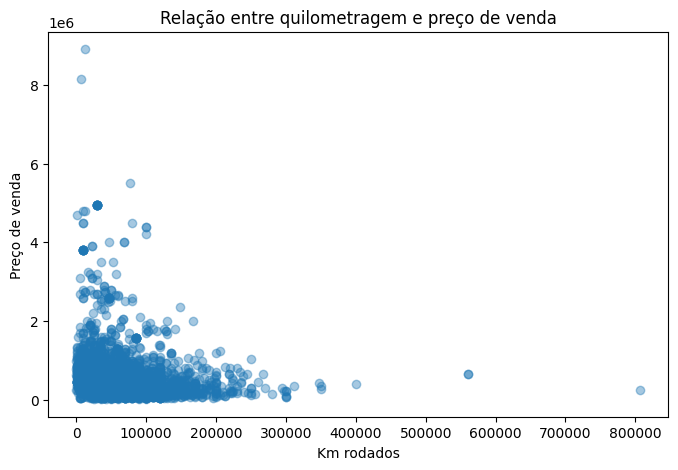

In [8]:
# Célula 08 - Relação entre quilometragem e preço

plt.figure(figsize=(8, 5))
plt.scatter(df["km_driven"], df["selling_price"], alpha=0.4)
plt.title("Relação entre quilometragem e preço de venda")
plt.xlabel("Km rodados")
plt.ylabel("Preço de venda")
plt.show()

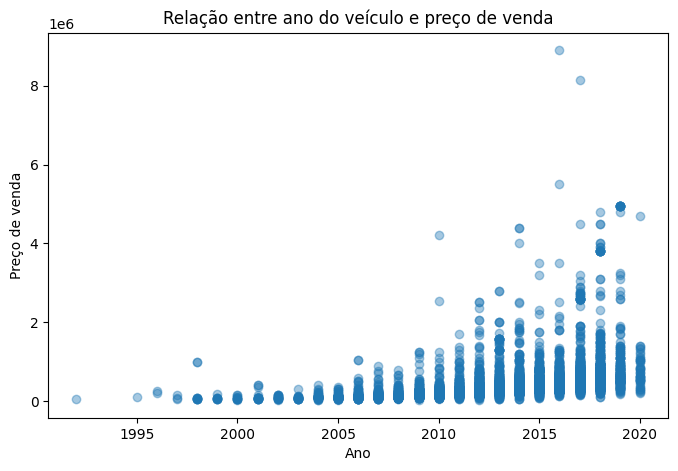

In [9]:
# Célula 09 - Relação entre ano e preço

plt.figure(figsize=(8, 5))
plt.scatter(df["year"], df["selling_price"], alpha=0.4)
plt.title("Relação entre ano do veículo e preço de venda")
plt.xlabel("Ano")
plt.ylabel("Preço de venda")
plt.show()

# 5. Preparação dos Dados

No exemplo do `housing.csv`, a coluna textual `ocean_proximity` foi removida.

Neste dataset, temos várias colunas textuais:

* `name`;
* `fuel`;
* `seller_type`;
* `transmission`;
* `owner`.

Para um primeiro modelo didático:

* vamos remover `name`, pois possui muitos nomes diferentes;
* vamos transformar as demais colunas categóricas com `pd.get_dummies()`;
* vamos criar a variável `car_age`, que representa a idade do carro.


In [10]:
# Célula 10 - Criando uma cópia para preparação dos dados

df_model = df.copy()

# Removendo duplicatas
df_model = df_model.drop_duplicates()

# Criando idade do carro
ANO_REFERENCIA = 2026
df_model["car_age"] = ANO_REFERENCIA - df_model["year"]

# Removendo colunas que não serão usadas diretamente
df_model = df_model.drop(columns=["name", "year"])

df_model.head()

,selling_price,km_driven,fuel,seller_type,transmission,owner,car_age
0,60000,70000,Petrol,Individual,Manual,First Owner,19
1,135000,50000,Petrol,Individual,Manual,First Owner,19
2,600000,100000,Diesel,Individual,Manual,First Owner,14
3,250000,46000,Petrol,Individual,Manual,First Owner,9
4,450000,141000,Diesel,Individual,Manual,Second Owner,12


In [11]:
# Célula 11 - Aplicando One-Hot Encoding nas variáveis categóricas

df_encoded = pd.get_dummies(
    df_model,
    columns=["fuel", "seller_type", "transmission", "owner"],
    drop_first=True
)

df_encoded.head()

,selling_price,km_driven,car_age,fuel_Diesel,fuel_Electric,fuel_LPG,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Manual,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
0,60000,70000,19,False,False,False,True,True,False,True,False,False,False,False
1,135000,50000,19,False,False,False,True,True,False,True,False,False,False,False
2,600000,100000,14,True,False,False,False,True,False,True,False,False,False,False
3,250000,46000,9,False,False,False,True,True,False,True,False,False,False,False
4,450000,141000,12,True,False,False,False,True,False,True,False,True,False,False


# 5.1. Mapa de Correlação (*Heatmap*)

Nesta etapa, vamos visualizar a correlação entre as variáveis numéricas já tratadas. O *heatmap* ajuda a identificar quais variáveis possuem maior relação com o preço de venda (`selling_price`).

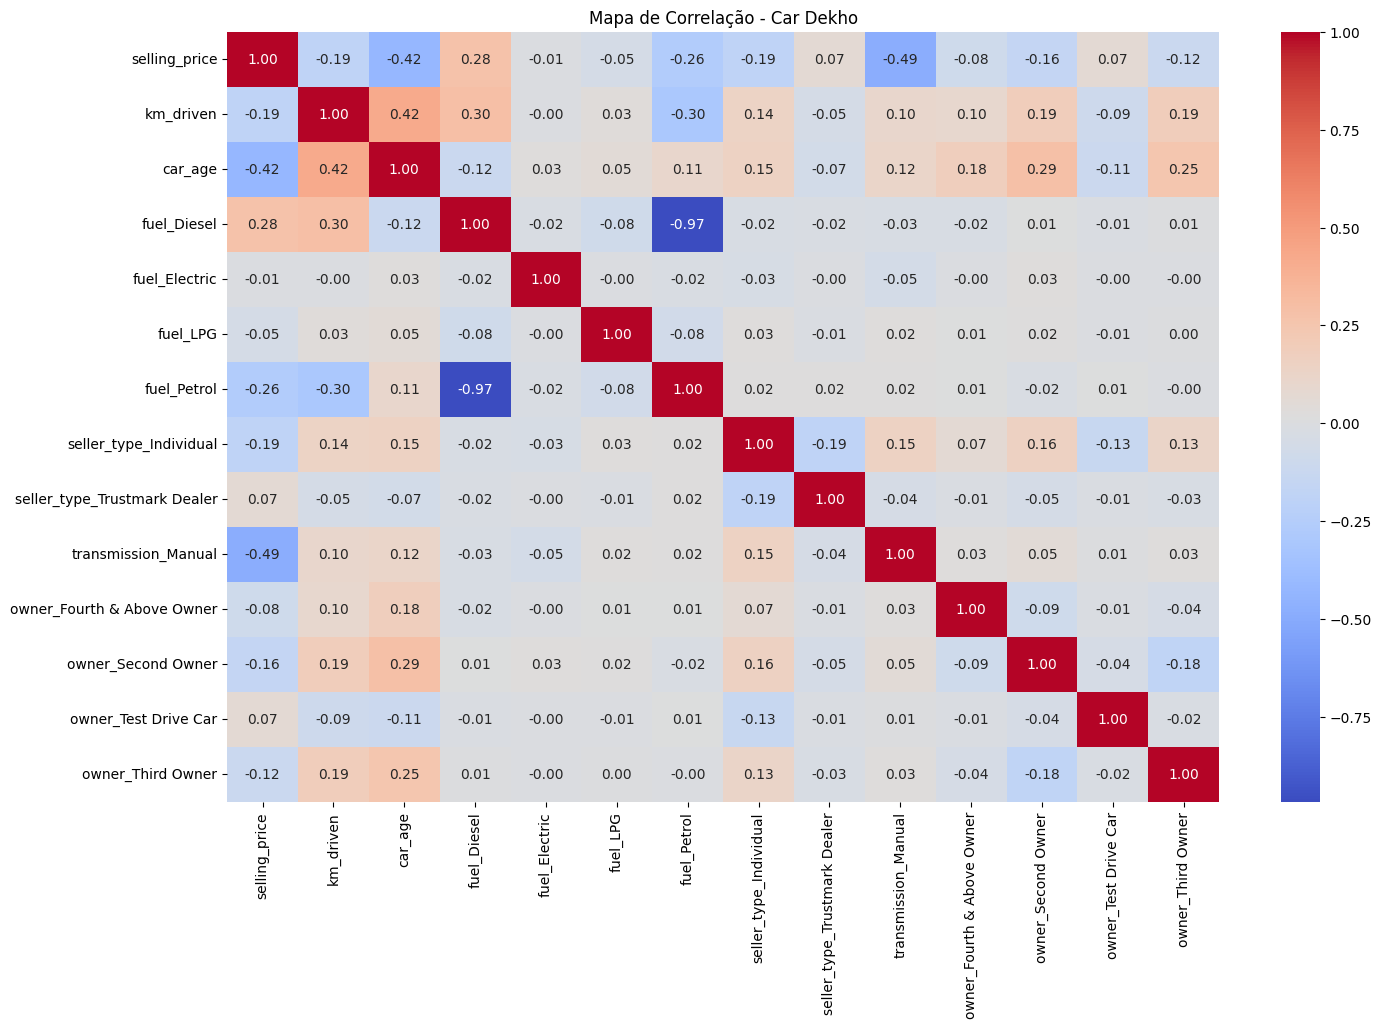

In [12]:
# Célula 12 - Heatmap de Correlação

# Importações necessárias para garantir que a célula funcione mesmo após reiniciar o kernel
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16, 10))

correlation = df_encoded.corr(numeric_only=True)

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Mapa de Correlação - Car Dekho")
plt.show()

In [13]:
# Célula 12 - Colunas após o tratamento

df_encoded.columns

Index(['selling_price', 'km_driven', 'car_age', 'fuel_Diesel', 'fuel_Electric',
       'fuel_LPG', 'fuel_Petrol', 'seller_type_Individual',
       'seller_type_Trustmark Dealer', 'transmission_Manual',
       'owner_Fourth & Above Owner', 'owner_Second Owner',
       'owner_Test Drive Car', 'owner_Third Owner'],
      dtype='str')

# 6. Separação entre Preditoras e Target

Assim como no exemplo do `housing.csv`, vamos separar:

* `preditoras`: variáveis usadas para prever;
* `target`: variável que queremos prever.

Aqui, a variável target será:

```python
selling_price
```


In [14]:
# Célula 13 - Separando as variáveis preditoras e a variável target

preditoras = df_encoded.drop(["selling_price"], axis=1)
target = df_encoded["selling_price"]

In [15]:
# Célula 14 - Visualizando as variáveis preditoras

preditoras.head()

,km_driven,car_age,fuel_Diesel,fuel_Electric,fuel_LPG,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Manual,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
0,70000,19,False,False,False,True,True,False,True,False,False,False,False
1,50000,19,False,False,False,True,True,False,True,False,False,False,False
2,100000,14,True,False,False,False,True,False,True,False,False,False,False
3,46000,9,False,False,False,True,True,False,True,False,False,False,False
4,141000,12,True,False,False,False,True,False,True,False,True,False,False


In [16]:
# Célula 15 - Visualizando a variável target

target.head()

0     60000
1    135000
2    600000
3    250000
4    450000
Name: selling_price, dtype: int64

# 7. Separação entre Treino e Teste

Vamos seguir a mesma ideia do exemplo do Random Forest:

* 70% dos dados para treino;
* 30% dos dados para teste.

O `random_state=42` garante que a divisão possa ser reproduzida.


In [17]:
# Célula 16 - Separando os dados em Treino (0.7) e Teste (0.3)

x_treino, x_teste, y_treino, y_teste = train_test_split(
    preditoras,
    target,
    test_size=0.3,
    random_state=42
)

In [18]:
# Célula 17 - Quantidade dos dados de treino e teste

print("x_treino:", x_treino.shape)
print("x_teste:", x_teste.shape)
print("y_treino:", y_treino.shape)
print("y_teste:", y_teste.shape)

x_treino: (2503, 13)
x_teste: (1074, 13)
y_treino: (2503,)
y_teste: (1074,)


# 8. Árvore de Decisão Simples

Antes de usar Random Forest, vamos criar uma única árvore de decisão.

Isso ajuda a entender a diferença entre:

* uma árvore isolada;
* várias árvores trabalhando em conjunto no Random Forest.

A métrica principal será o **RMSE**:

```text
RMSE = raiz do erro quadrático médio
```

Quanto menor o RMSE, melhor o modelo.


In [19]:
# Célula 18 - Criando uma árvore de decisão simples

# Criando o modelo
arvore = DecisionTreeRegressor(random_state=42)

# Treinando o modelo
arvore.fit(x_treino, y_treino)

# Gerando as previsões
previsao = arvore.predict(x_teste)

# Visualizando o RMSE
rmse = np.sqrt(mean_squared_error(y_teste, previsao))
mae = mean_absolute_error(y_teste, previsao)
r2 = r2_score(y_teste, previsao)

print("Decision Tree Regressor")
print("RMSE:", rmse)
print("MAE:", mae)
print("R²:", r2)

Decision Tree Regressor
RMSE: 560491.0046795448
MAE: 247294.0357736718
R²: -0.019340517872232343


## Considerações Importantes

Quanto maior a profundidade de uma árvore, maior a chance de ela decorar os dados de treino.

Isso é chamado de **overfitting**.

Para observar esse comportamento, vamos testar árvores com diferentes profundidades:

* `max_depth = 1`;
* `max_depth = 2`;
* `max_depth = 3`.


In [20]:
# Célula - Árvore de decisão com max_depth = 1

arvore = DecisionTreeRegressor(max_depth=1, random_state=42)

arvore.fit(x_treino, y_treino)

previsao = arvore.predict(x_teste)

rmse = np.sqrt(mean_squared_error(y_teste, previsao))

print("RMSE com max_depth = 1:", rmse)

RMSE com max_depth = 1: 482556.4827921025


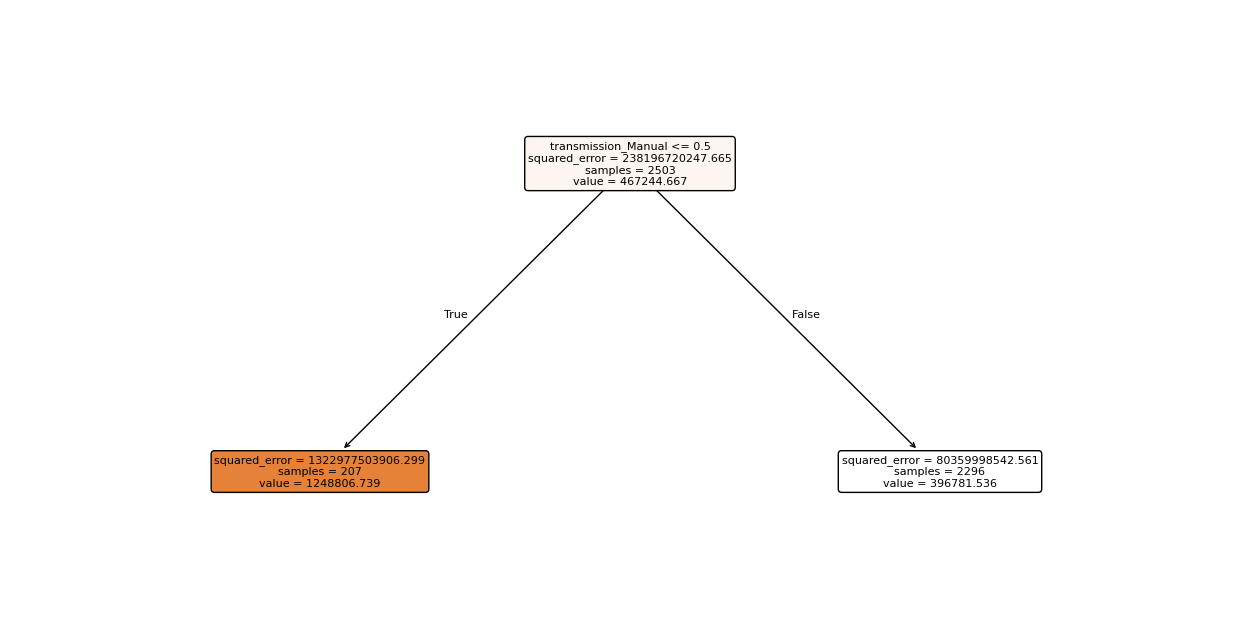

In [21]:
# Visualizando a árvore com max_depth = 1

plt.figure(figsize=(16, 8))
plot_tree(
    arvore,
    feature_names=x_treino.columns,
    filled=True,
    rounded=True,
    fontsize=8
)
plt.show()

In [22]:
# Célula - Árvore de decisão com max_depth = 2

arvore = DecisionTreeRegressor(max_depth=2, random_state=42)

arvore.fit(x_treino, y_treino)

previsao = arvore.predict(x_teste)

rmse = np.sqrt(mean_squared_error(y_teste, previsao))

print("RMSE com max_depth = 2:", rmse)

RMSE com max_depth = 2: 439206.83202856


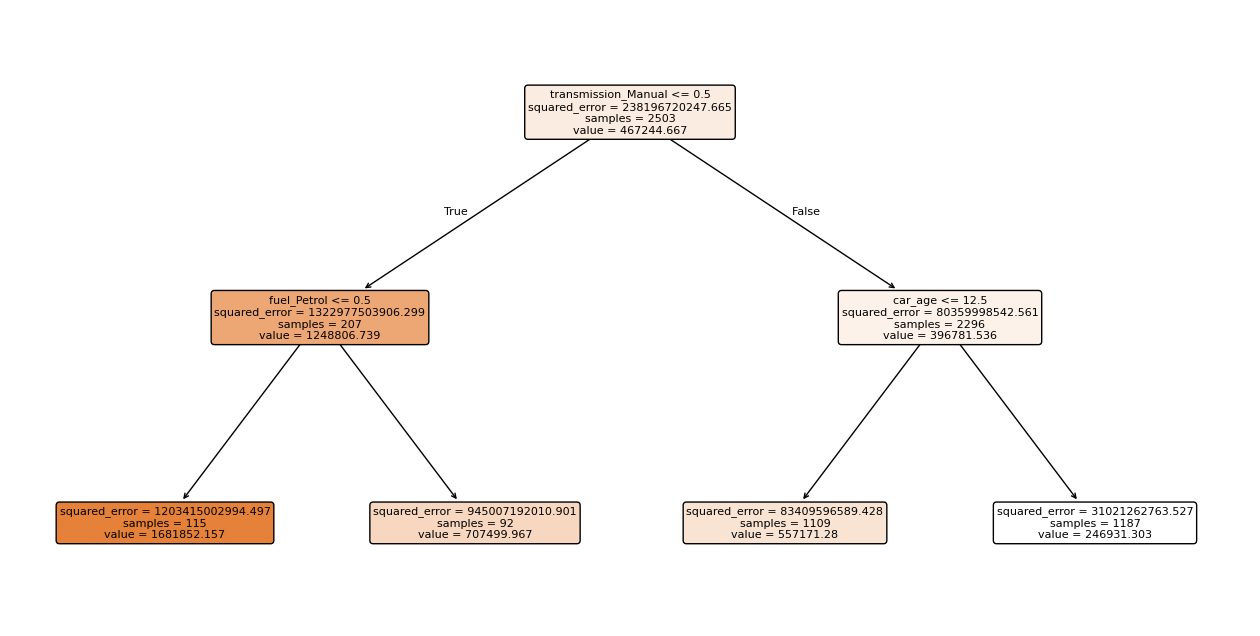

In [23]:
# Visualizando a árvore com max_depth = 2

plt.figure(figsize=(16, 8))
plot_tree(
    arvore,
    feature_names=x_treino.columns,
    filled=True,
    rounded=True,
    fontsize=8
)
plt.show()

In [24]:
# Célula - Árvore de decisão com max_depth = 3

arvore = DecisionTreeRegressor(max_depth=3, random_state=42)

arvore.fit(x_treino, y_treino)

previsao = arvore.predict(x_teste)

rmse = np.sqrt(mean_squared_error(y_teste, previsao))

print("RMSE com max_depth = 3:", rmse)

RMSE com max_depth = 3: 407507.2102427922


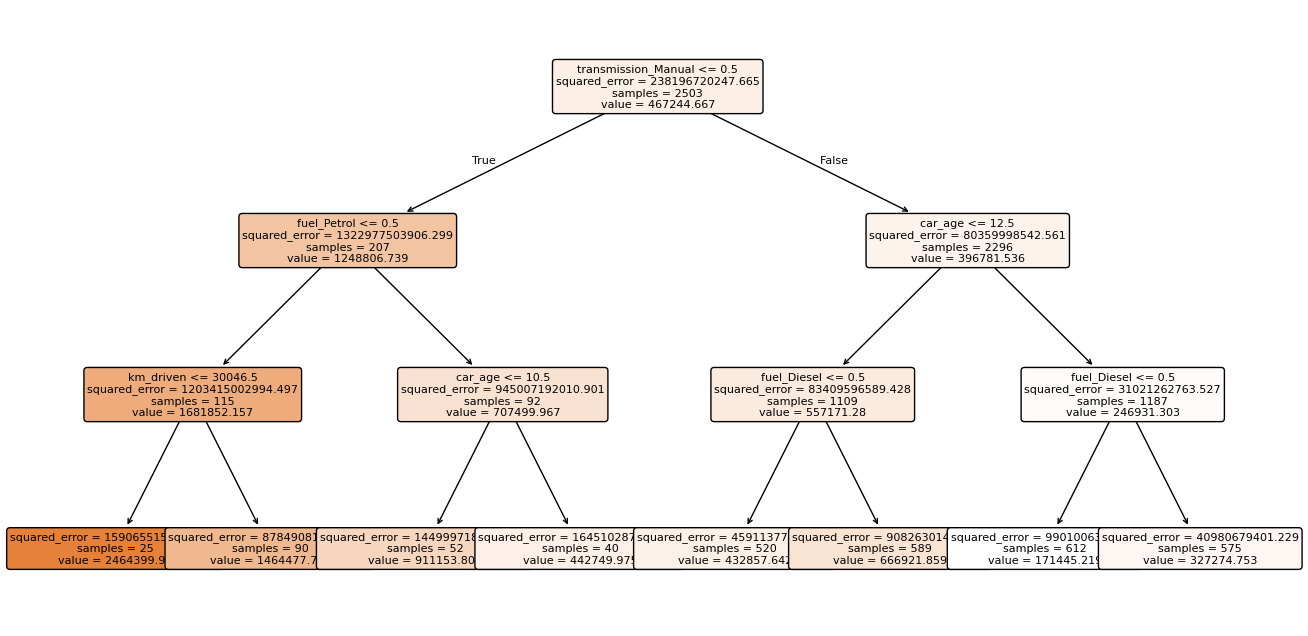

In [25]:
# Visualizando a árvore com max_depth = 3

plt.figure(figsize=(16, 8))
plot_tree(
    arvore,
    feature_names=x_treino.columns,
    filled=True,
    rounded=True,
    fontsize=8
)
plt.show()

# 9. Random Forest

Agora vamos aplicar o algoritmo **Random Forest Regressor**.

A ideia do Random Forest é criar várias árvores de decisão e combinar seus resultados.

Para problemas de regressão, o resultado final normalmente é a **média das previsões das árvores**.


In [26]:
# Célula 25 - Criando o algoritmo Random Forest

# O padrão são 100 árvores.
arvores = RandomForestRegressor(random_state=42)

# Treinando o algoritmo
inicio = time.time()
arvores.fit(x_treino, y_treino)
fim = time.time()

# Gerando as previsões
previsao = arvores.predict(x_teste)

# Avaliação
rmse = np.sqrt(mean_squared_error(y_teste, previsao))
mae = mean_absolute_error(y_teste, previsao)
r2 = r2_score(y_teste, previsao)

print("Random Forest Regressor")
print("RMSE:", rmse)
print("MAE:", mae)
print("R²:", r2)
print("Tempo de treino do modelo:", fim - inicio)

Random Forest Regressor
RMSE: 415592.0002343927
MAE: 201166.03040669308
R²: 0.4395764823340206
Tempo de treino do modelo: 0.5565235614776611


In [27]:
# Célula 26 - Criando o algoritmo usando n_jobs=-1

# n_jobs=-1 usa todos os núcleos disponíveis do processador.
arvores = RandomForestRegressor(random_state=42, n_jobs=-1)

inicio = time.time()
arvores.fit(x_treino, y_treino)
fim = time.time()

previsao = arvores.predict(x_teste)

rmse = np.sqrt(mean_squared_error(y_teste, previsao))

print("RMSE:", rmse)
print("Tempo de treino do modelo:", fim - inicio)

RMSE: 415592.0002343927
Tempo de treino do modelo: 0.25808048248291016


# 10. Testando Hiperparâmetros

Agora vamos testar algumas configurações do Random Forest:

* número de árvores (`n_estimators`);
* profundidade máxima das árvores (`max_depth`).

Esses ajustes são chamados de **hiperparâmetros**.


In [28]:
# Célula 27 - Modelo com 300 árvores

arvores = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

arvores.fit(x_treino, y_treino)

previsao = arvores.predict(x_teste)

np.sqrt(mean_squared_error(y_teste, previsao))

np.float64(418508.3624878721)

In [29]:
# Célula 28 - Modelo com 300 árvores e max_depth = 2

arvores = RandomForestRegressor(
    n_estimators=300,
    max_depth=2,
    random_state=42,
    n_jobs=-1
)

arvores.fit(x_treino, y_treino)

previsao = arvores.predict(x_teste)

np.sqrt(mean_squared_error(y_teste, previsao))

np.float64(434937.15031716117)

In [30]:
# Célula 29 - Modelo com 300 árvores e max_depth = 20

arvores = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

arvores.fit(x_treino, y_treino)

previsao = arvores.predict(x_teste)

np.sqrt(mean_squared_error(y_teste, previsao))

np.float64(418451.335598821)

# 11. Visualizando o Funcionamento do Random Forest

Vamos criar um Random Forest pequeno, com apenas 5 árvores, para conseguir visualizar o funcionamento.

Como cada árvore aprende de uma forma um pouco diferente, o conjunto delas tende a gerar uma previsão mais estável.


In [31]:
# Célula 30 - Criando um modelo com 5 árvores e profundidade 2

arvores = RandomForestRegressor(
    n_estimators=5,
    max_depth=2,
    random_state=42,
    n_jobs=-1
)

arvores.fit(x_treino, y_treino)

previsao = arvores.predict(x_teste)

np.sqrt(mean_squared_error(y_teste, previsao))

np.float64(436578.38648944855)

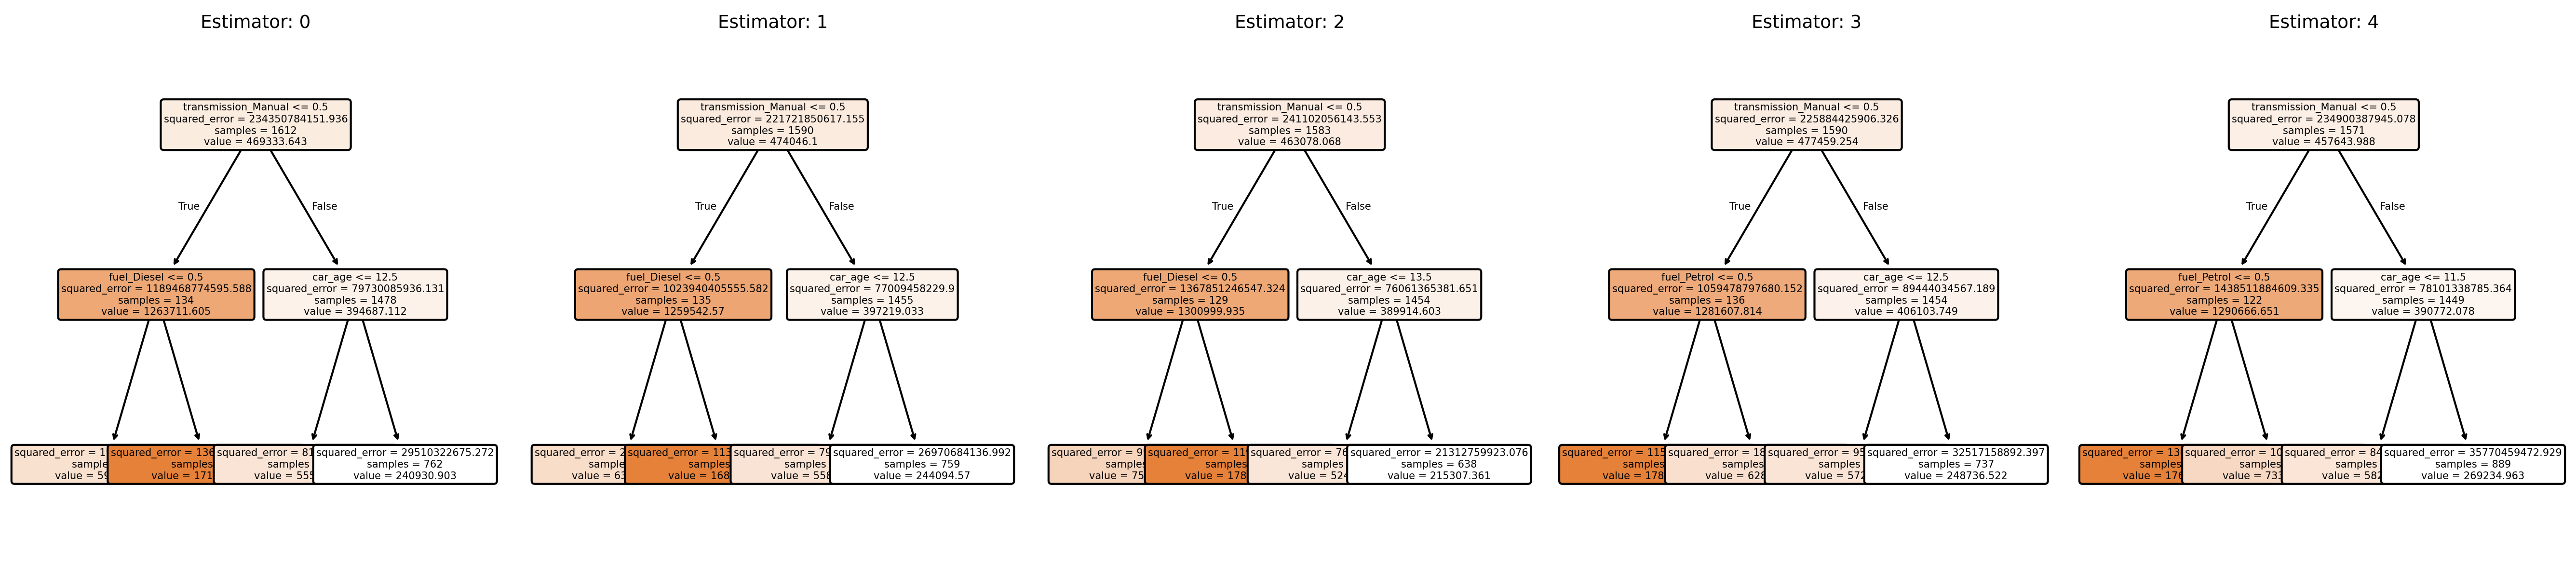

In [32]:
# Célula 31 - Visualizando as 5 árvores do Random Forest

fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(18, 4), dpi=300)

for index in range(0, 5):
    plot_tree(
        arvores.estimators_[index],
        feature_names=x_treino.columns,
        filled=True,
        rounded=True,
        fontsize=5,
        ax=axes[index]
    )
    axes[index].set_title("Estimator: " + str(index), fontsize=9)

plt.tight_layout()
plt.show()

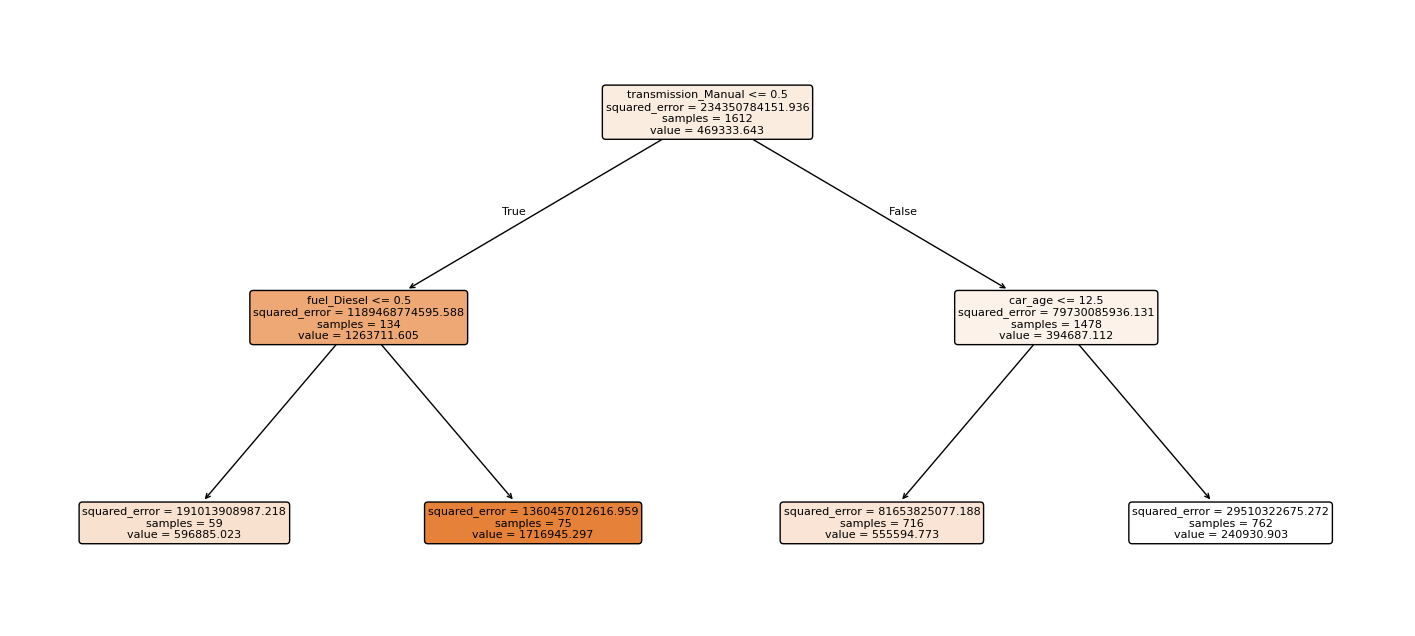

In [33]:
# Célula 32 - Visualizando uma árvore individual do Random Forest

plt.figure(figsize=(18, 8))
plot_tree(
    arvores.estimators_[0],
    feature_names=x_treino.columns,
    filled=True,
    rounded=True,
    fontsize=8
)
plt.show()

## Visualização de Árvores Individuais do Random Forest

Assim como no exemplo do `housing.csv`, também podemos visualizar árvores individuais do conjunto Random Forest.

Cada árvore pode apresentar uma estrutura diferente, pois o algoritmo utiliza amostras e combinações diferentes dos dados durante o treinamento.


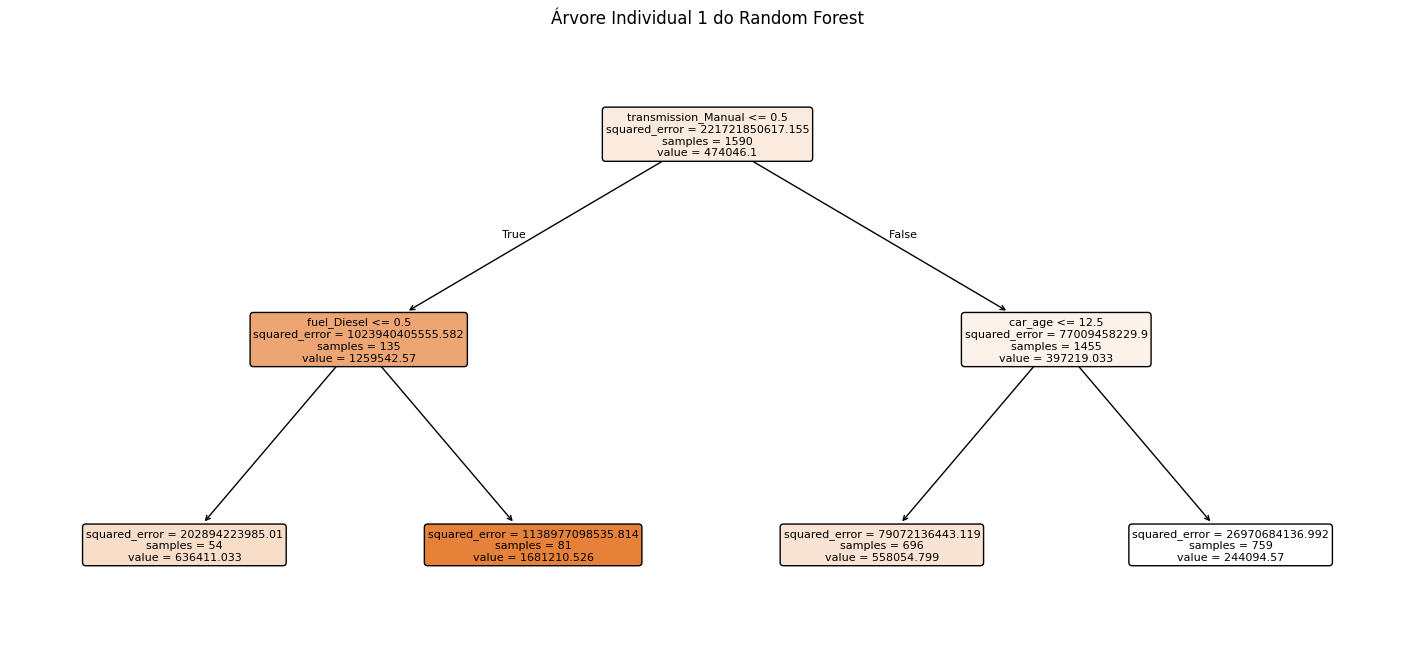

In [34]:
# Célula Extra - Visualizando a árvore individual 1 do Random Forest

plt.figure(figsize=(18, 8))
plot_tree(
    arvores.estimators_[1],
    feature_names=x_treino.columns,
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Árvore Individual 1 do Random Forest")
plt.show()


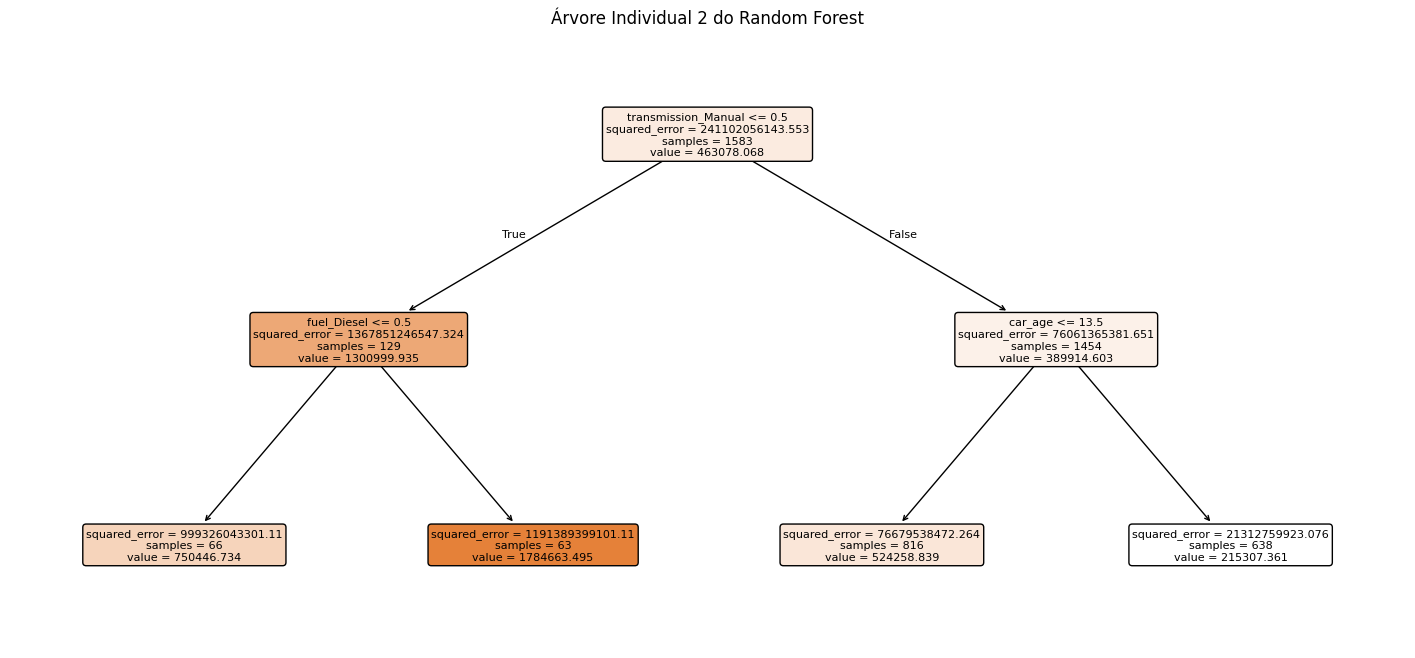

In [35]:
# Célula Extra - Visualizando a árvore individual 2 do Random Forest

plt.figure(figsize=(18, 8))
plot_tree(
    arvores.estimators_[2],
    feature_names=x_treino.columns,
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Árvore Individual 2 do Random Forest")
plt.show()


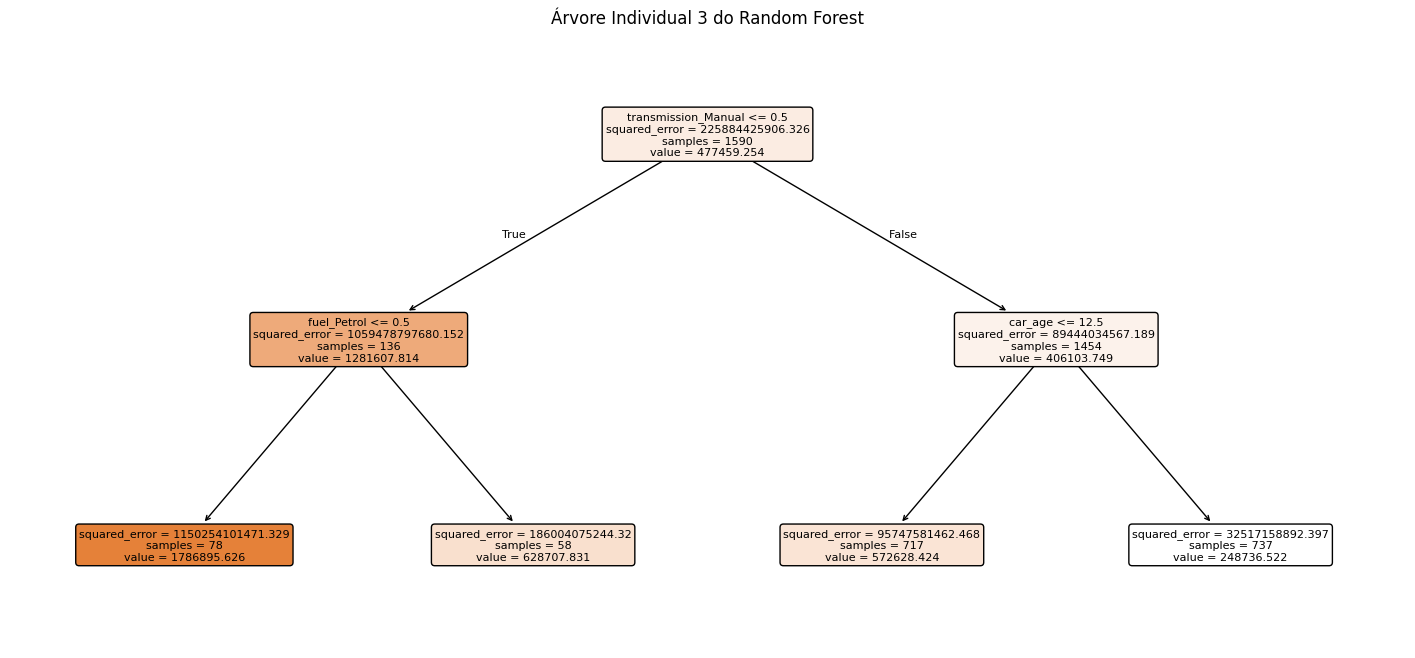

In [36]:
# Célula Extra - Visualizando a árvore individual 3 do Random Forest

plt.figure(figsize=(18, 8))
plot_tree(
    arvores.estimators_[3],
    feature_names=x_treino.columns,
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Árvore Individual 3 do Random Forest")
plt.show()


In [37]:
# Célula 33 - Criando um modelo com 5 árvores e profundidade 3

arvores = RandomForestRegressor(
    n_estimators=5,
    max_depth=3,
    random_state=42,
    n_jobs=-1
)

arvores.fit(x_treino, y_treino)

previsao = arvores.predict(x_teste)

np.sqrt(mean_squared_error(y_teste, previsao))

np.float64(397422.5455886137)

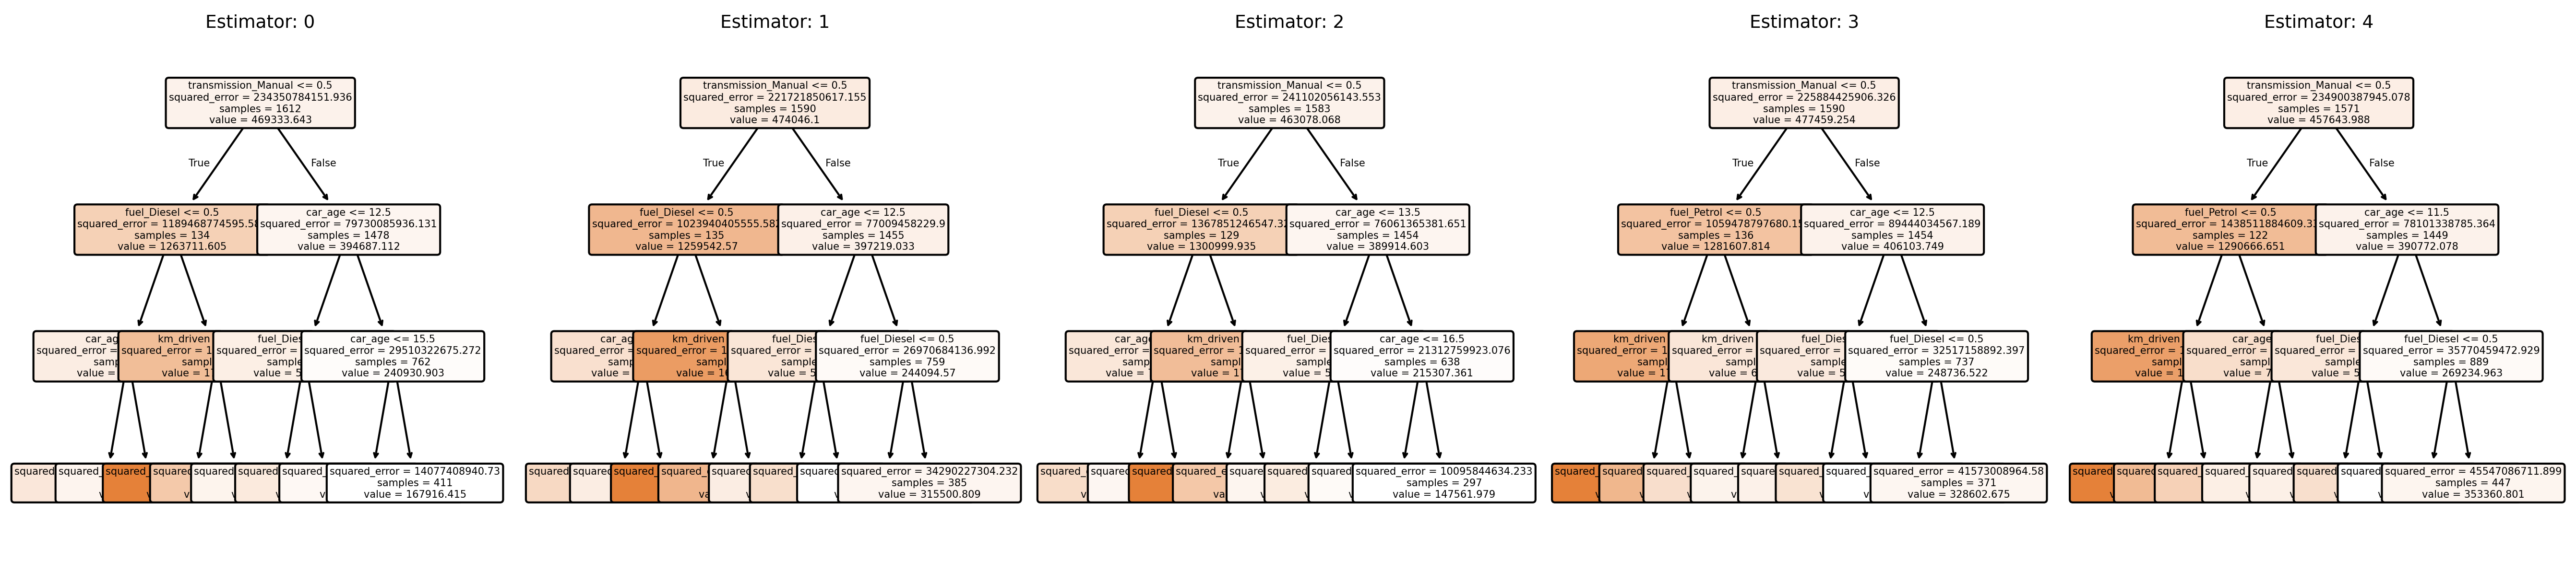

In [38]:
# Célula 34 - Visualizando as 5 árvores com max_depth = 3

fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(18, 4), dpi=300)

for index in range(0, 5):
    plot_tree(
        arvores.estimators_[index],
        feature_names=x_treino.columns,
        filled=True,
        rounded=True,
        fontsize=5,
        ax=axes[index]
    )
    axes[index].set_title("Estimator: " + str(index), fontsize=9)

plt.tight_layout()
plt.show()

# 12. Modelo Final

Agora vamos treinar um modelo final de Random Forest com uma configuração mais robusta.

Em seguida, vamos avaliar:

* RMSE;
* MAE;
* R²;
* comparação entre preço real e preço previsto.


In [39]:
# Célula 35 - Modelo final

modelo_final = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

modelo_final.fit(x_treino, y_treino)

previsao_final = modelo_final.predict(x_teste)

rmse_final = np.sqrt(mean_squared_error(y_teste, previsao_final))
mae_final = mean_absolute_error(y_teste, previsao_final)
r2_final = r2_score(y_teste, previsao_final)

print("Modelo Final - Random Forest")
print("RMSE:", rmse_final)
print("MAE:", mae_final)
print("R²:", r2_final)

Modelo Final - Random Forest
RMSE: 418451.335598821
MAE: 201912.68717663496
R²: 0.4318383579623629


In [40]:
# Célula 36 - Comparação entre valores reais e previstos

comparacao = pd.DataFrame({
    "Preço real": y_teste.values,
    "Preço previsto": previsao_final
})

comparacao.head(10)

,Preço real,Preço previsto
0,270000,4.836107e+05
1,525000,6.090617e+05
2,990000,1.393158e+06
3,3800000,2.436496e+06
4,229999,1.085072e+05
5,325000,3.618778e+05
6,210000,1.771156e+05
7,500000,6.512437e+05
8,790000,9.165220e+05
9,360000,2.468064e+05


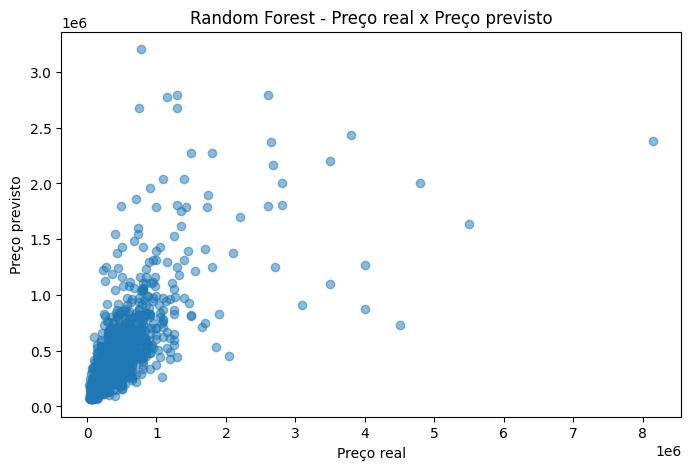

In [41]:
# Célula 37 - Gráfico: preço real x preço previsto

plt.figure(figsize=(8, 5))
plt.scatter(y_teste, previsao_final, alpha=0.5)

plt.xlabel("Preço real")
plt.ylabel("Preço previsto")
plt.title("Random Forest - Preço real x Preço previsto")

plt.show()

# 13. Importância das Variáveis

Uma vantagem do Random Forest é permitir visualizar quais variáveis tiveram maior importância no modelo.

Isso ajuda a interpretar o modelo e entender quais características mais influenciaram o preço do veículo.


In [42]:
# Célula 38 - Importância das variáveis

importancias = pd.DataFrame({
    "feature": x_treino.columns,
    "importance": modelo_final.feature_importances_
}).sort_values(by="importance", ascending=False)

importancias

,feature,importance
1,car_age,0.282224
0,km_driven,0.274338
8,transmission_Manual,0.243840
2,fuel_Diesel,0.084141
5,fuel_Petrol,0.044745
6,seller_type_Individual,0.033208
10,owner_Second Owner,0.023764
11,owner_Test Drive Car,0.005401
12,owner_Third Owner,0.004794
7,seller_type_Trustmark Dealer,0.002267


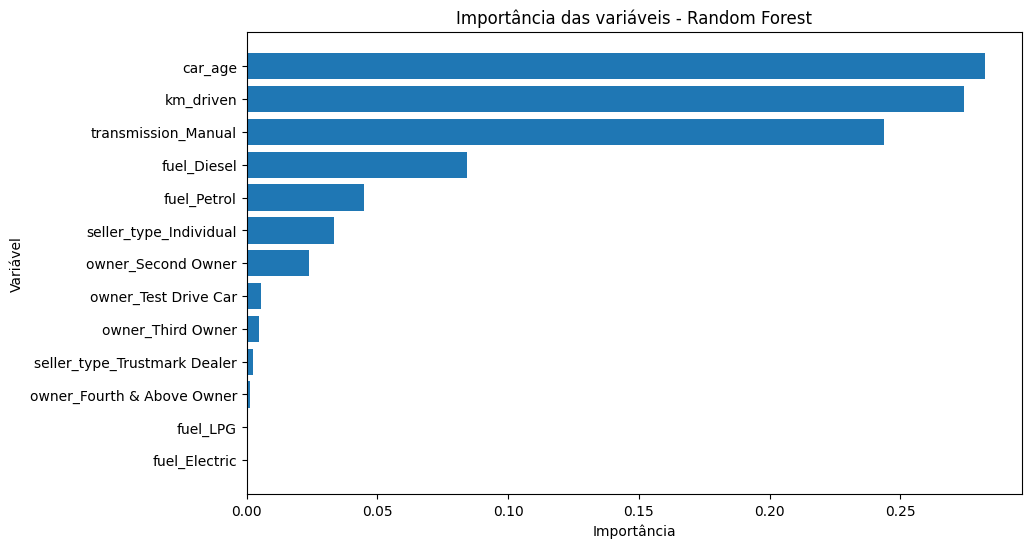

In [43]:
# Célula 39 - Gráfico de importância das variáveis

plt.figure(figsize=(10, 6))
plt.barh(importancias["feature"], importancias["importance"])
plt.gca().invert_yaxis()

plt.title("Importância das variáveis - Random Forest")
plt.xlabel("Importância")
plt.ylabel("Variável")

plt.show()

# Resumo

Neste notebook, seguimos a lógica do exemplo de Random Forest com `housing.csv`, porém usando o dataset **Car Dekho**.

## Etapas realizadas

1. Carregamos o dataset;
2. Visualizamos a estrutura dos dados;
3. Removemos duplicatas;
4. Criamos a variável `car_age`;
5. Transformamos variáveis categóricas com `pd.get_dummies()`;
6. Separamos preditoras e target;
7. Dividimos os dados em treino e teste;
8. Treinamos uma árvore de decisão simples;
9. Testamos árvores com diferentes profundidades;
10. Treinamos modelos Random Forest;
11. Testamos hiperparâmetros;
12. Visualizamos árvores do Random Forest;
13. Avaliamos o modelo final;
14. Analisamos a importância das variáveis.

## Conclusão

O Random Forest tende a apresentar melhor desempenho do que uma única árvore de decisão, pois combina várias árvores e reduz a chance de erro causado por uma árvore individual.
